In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, StandardScaler
import os
import json
import numpy as np

In [2]:
inds = pd.read_pickle("/mnt/disks/data/ace_dscovr_index.pkl")

In [3]:
inds = inds.drop_duplicates()

In [4]:
comp = "z"
db = pd.DataFrame()
for year in range(2001, 2025):
    print(year)
    filename = f"formatted_db{comp}_geo_{year}.csv"
    data = pd.read_csv(
        "/mnt/disks/data/" + filename, parse_dates=True, index_col="time", header=0
    )
    sm_ind = data.index.intersection(inds)
    db = pd.concat([db, data.loc[sm_ind]])

2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024


In [5]:
db

,A01,A02,A03,A04,A05,A06,A07,A08,A09,A10,...,Y16,Y17,Y18,YAK,YAP,YKC,YOR,ZAG,ZGN,ZYK
time,,,,,,,,,,,,,,,,,,,,,
2001-08-11 15:27:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.979867,-47.087875,NaN,NaN,NaN
2001-08-11 15:28:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.968464,-47.231476,NaN,NaN,NaN
2001-08-11 15:29:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.951981,-47.465400,NaN,NaN,NaN
2001-08-11 15:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-1.937779,-47.624344,NaN,NaN,NaN
2001-08-11 15:31:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-1.922808,-47.739037,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31 05:59:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-31 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-31 06:01:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


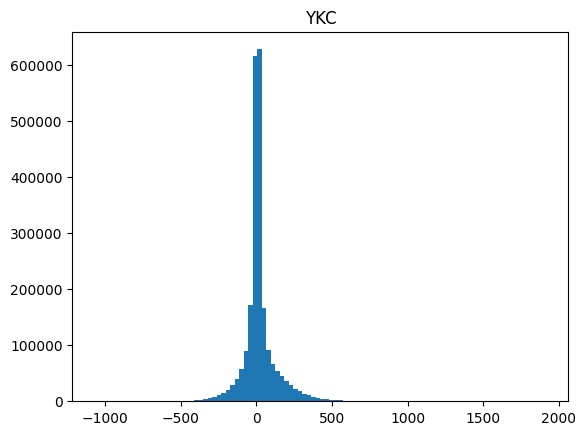

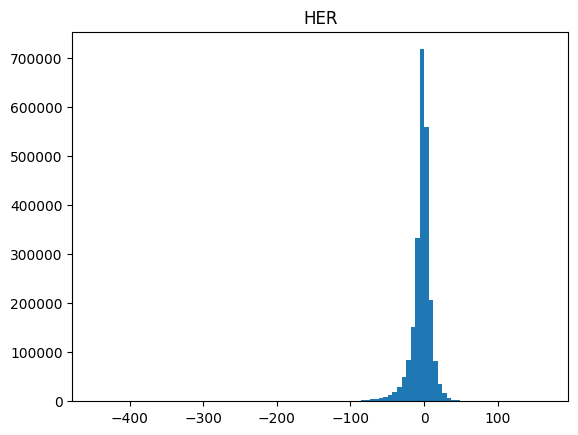

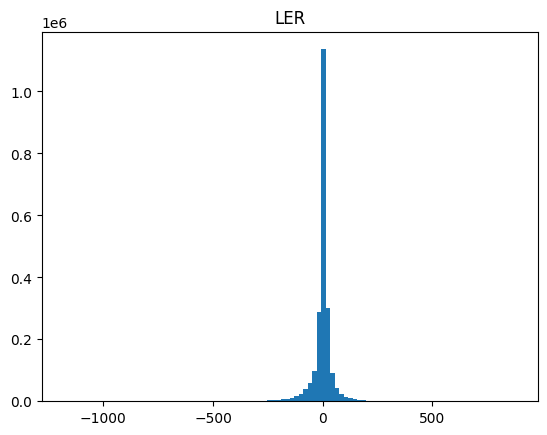

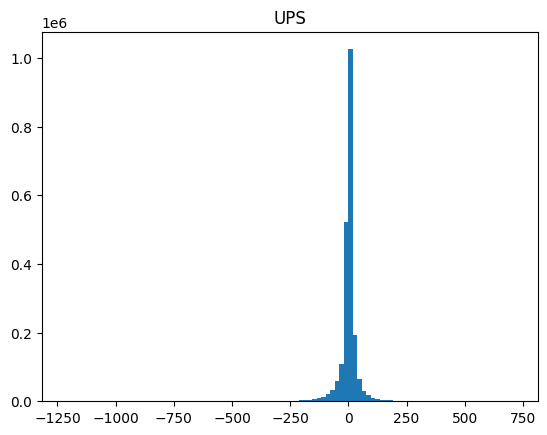

In [6]:
# plot a selection of stations distributions
for i in ["YKC", "HER", "LER", "UPS"]:
    plt.hist(db[i], bins=100)
    plt.title(i)
    plt.show()

In [7]:
scaler = StandardScaler()
db_scaler = scaler.fit(db)

/opt/conda/envs/fdl/lib/python3.10/site-packages/sklearn/utils/extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/conda/envs/fdl/lib/python3.10/site-packages/sklearn/utils/extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/conda/envs/fdl/lib/python3.10/site-packages/sklearn/utils/extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [8]:
def save_scaler(scaler, scaler_dir, filename):
    """
    Saves a PowerTransfomer(method='yeo-johnson', standardize=True) object to a JSON file.

    Args:
        scaler (PowerTransfomer): The scaler object to save.
        filename (str): Name of the JSON file to save the scaler.
    """
    std_scaler_dict = {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "n_features": scaler.n_features_in_,
        "feature_names": scaler.feature_names_in_.tolist(),
    }

    with open(os.path.join(scaler_dir, "std_" + filename), "w") as f:
        json.dump(std_scaler_dict, f)

In [9]:
save_scaler(scaler, ".", f"db{comp}_scaler.json")

In [10]:
def load_scaler(scaler_dir, filename):
    """
    Loads a PowerTransformer and associated StandardScaler object from JSON files.

    Args:
        filename (str): Name of the JSON file containing the scaler.

    Returns:
        PowerTransformer: The loaded scaler object.
    """

    with open(os.path.join(scaler_dir, "std_" + filename), "r") as f:
        std_scaler_dict = json.load(f)
    std_scaler = StandardScaler()
    std_scaler.mean_ = np.array(std_scaler_dict["mean"])
    std_scaler.scale_ = np.array(std_scaler_dict["scale"])
    std_scaler.var_ = np.array(std_scaler_dict["var"])
    std_scaler.n_features_in_ = std_scaler_dict["n_features"]
    std_scaler.feature_names_in_ = np.array(std_scaler_dict["feature_names"])

    return std_scaler

In [11]:
# apply the scaler to the data - note the double step to include the standardization from the original fit
std_tst = load_scaler(".", f"db{comp}_scaler.json")
std_tst.set_output(transform="pandas")

StandardScaler()

In [12]:
full_data_fitted = std_tst.transform(db)

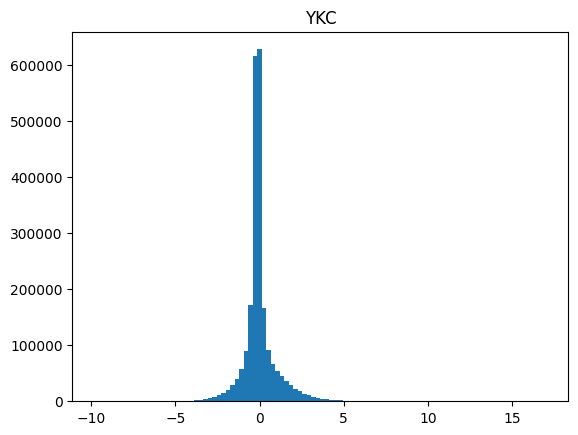

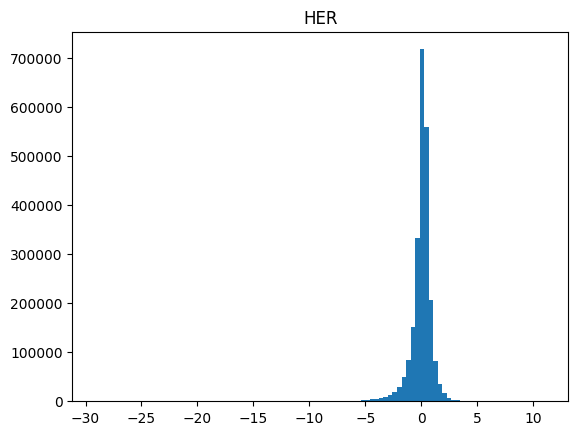

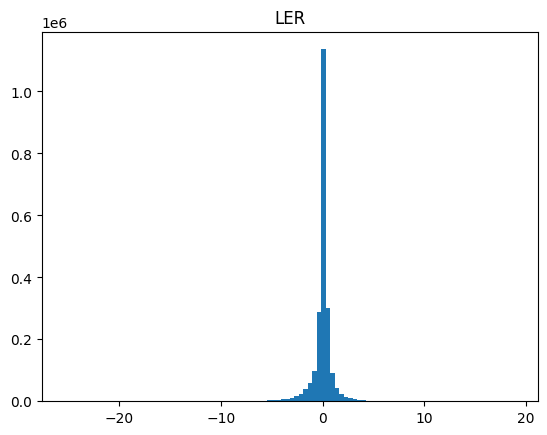

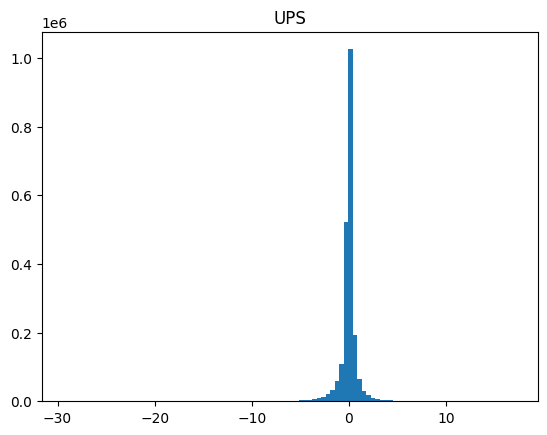

In [13]:
for i in ["YKC", "HER", "LER", "UPS"]:
    plt.hist(full_data_fitted[i], bins=100)
    plt.title(i)
    plt.show()